## Part I

#### 1. Construct the Dataset

In [4]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import numpy as np

In [5]:
# Load data

epu = pd.read_excel('data/US_Policy_Uncertainty_Data.xlsx')
epu['date'] = (
    epu['Year'].astype('Int64').astype(str) 
    + "-" + 
    epu['Month'].astype('Int64').astype(str).str.zfill(2)
)
epu['date'] = pd.to_datetime(epu['date'], format='%Y-%m')
epu = epu[(epu['date']<='2023-03') & (epu['date']>='1985-01')]
epu = epu[['News_Based_Policy_Uncert_Index', 'date']]

payems = pd.read_csv('data/PAYEMS.csv')
payems['observation_date'] = pd.to_datetime(payems['observation_date'])

pcepi = pd.read_csv('data/PCEPI.csv')
pcepi['observation_date'] = pd.to_datetime(pcepi['observation_date'])

indpro = pd.read_csv('data/INDPRO.csv')
indpro['observation_date'] = pd.to_datetime(indpro['observation_date'])

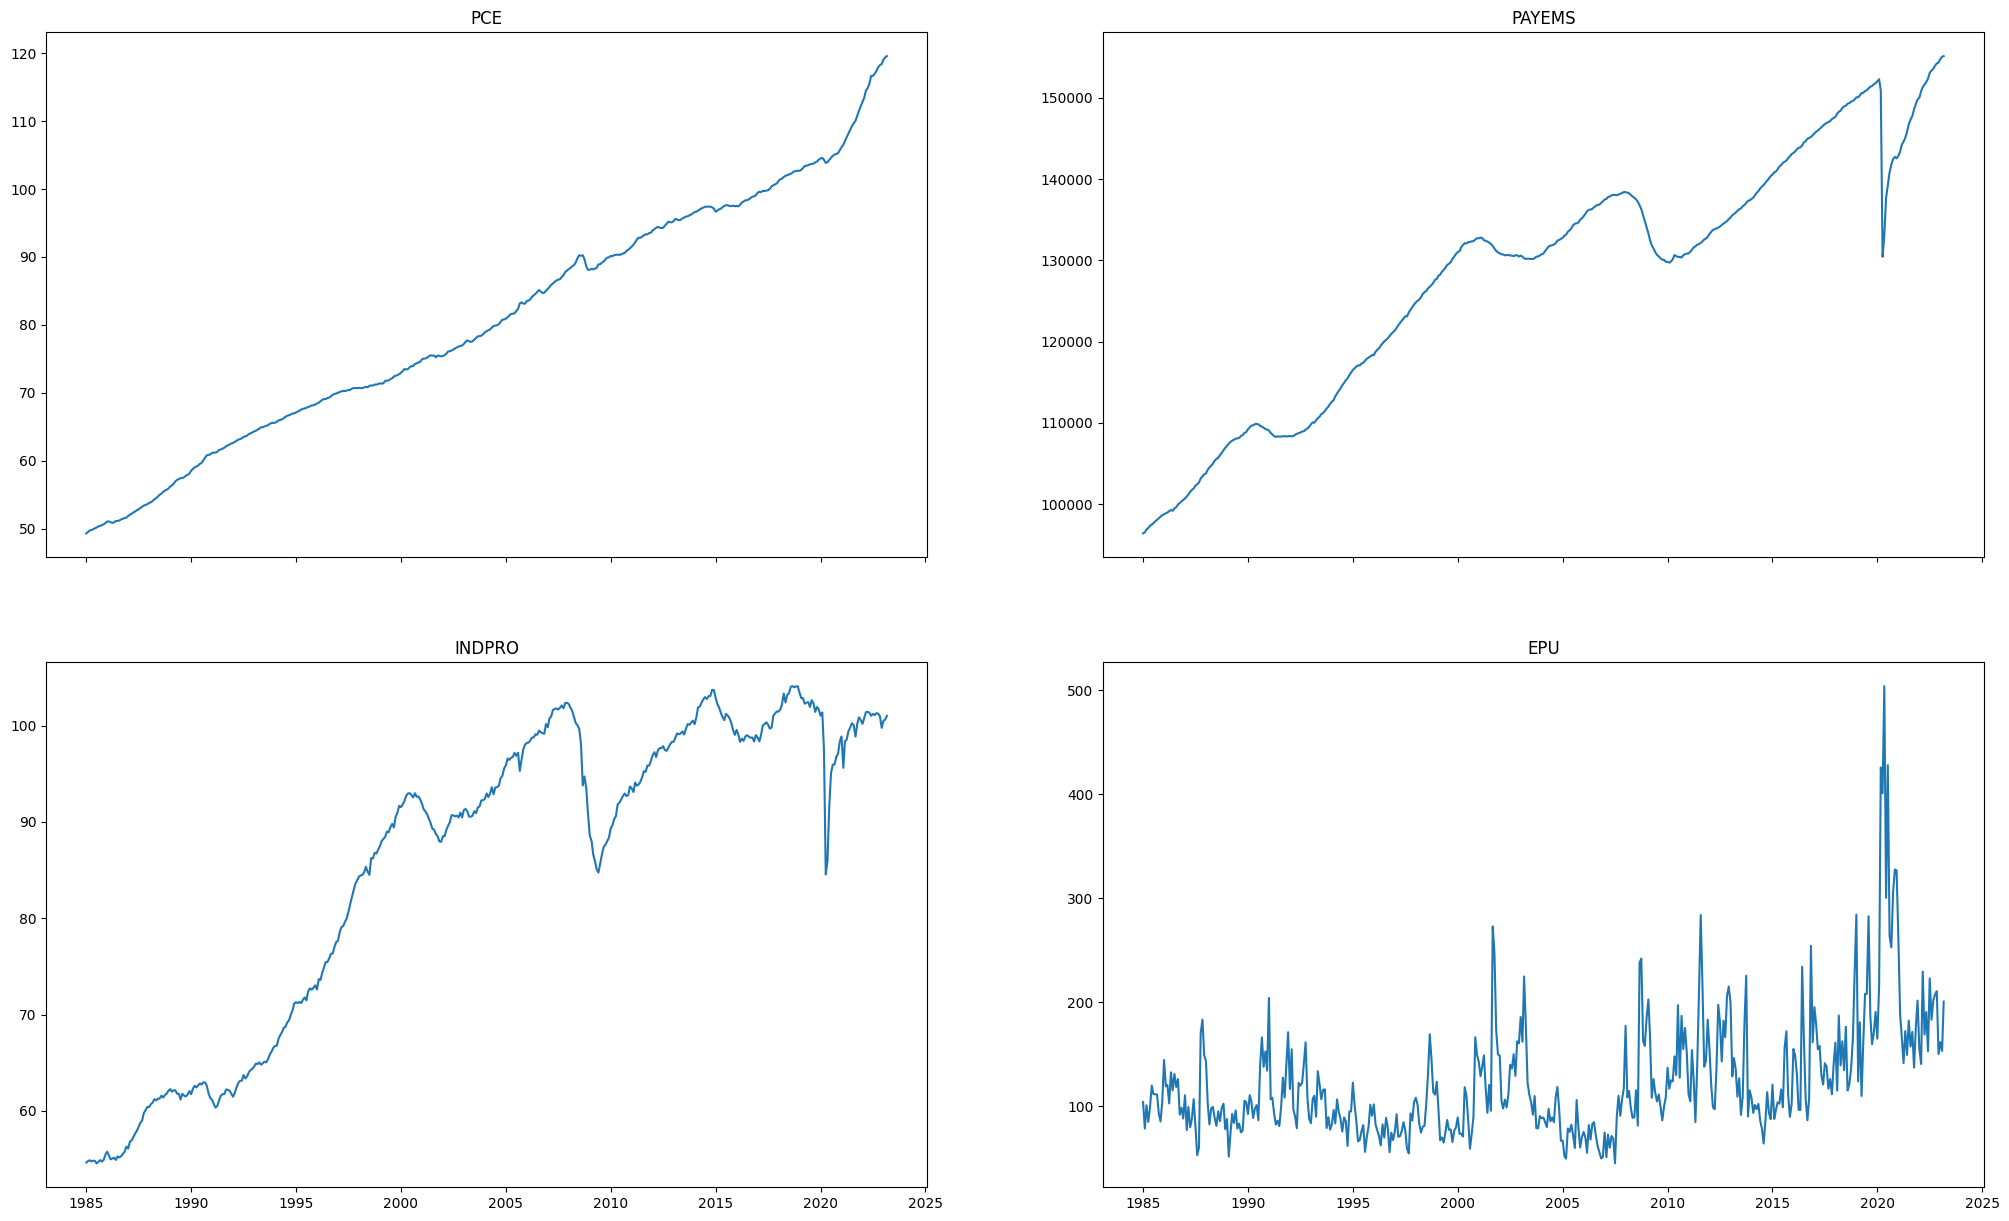

In [6]:
# Check for data shape

fig, ax = plt.subplots(2,2,figsize=(25,15), sharex=True)

ax[0][1].plot(payems['observation_date'], payems['PAYEMS'])
ax[0][1].set_title('PAYEMS')

ax[0][0].plot(pcepi['observation_date'], pcepi['PCEPI'])
ax[0][0].set_title('PCE')

ax[1][0].plot(indpro['observation_date'], indpro['INDPRO'])
ax[1][0].set_title('INDPRO')

ax[1][1].plot(epu['date'], epu['News_Based_Policy_Uncert_Index'])
ax[1][1].set_title('EPU')

plt.show()

In [7]:
# Merge data and build dataset

data = epu.set_index('date').join(pcepi.set_index('observation_date')).join(payems.set_index('observation_date')).join(indpro.set_index('observation_date'))
data = data.rename(columns={data.columns[0]: 'EPU'})
data

,EPU,PCEPI,PAYEMS,INDPRO
date,,,,
2023-03-01,200.489936,119.538,155134,101.0205
2023-02-01,152.967281,119.369,155066,100.6416
2023-01-01,161.427114,119.018,154776,100.5050
2022-12-01,150.037124,118.384,154342,99.7664
2022-11-01,210.374894,118.224,154242,100.9552
...,...,...,...,...
1985-05-01,98.053653,49.939,97312,54.8255
1985-04-01,84.778863,49.821,97038,54.7459
1985-03-01,100.761475,49.749,96842,54.8653


#### 2. VAR Estimation

In [8]:
# Variables to month-on-month growth rates

var_data = data.copy()
var_data = var_data.sort_index()

var_data['PAYEMS_growth'] = var_data['PAYEMS'].pct_change() * 100
var_data['INDPRO_growth'] = var_data['INDPRO'].pct_change() * 100
var_data['PCEPI_growth'] = var_data['PCEPI'].pct_change() * 100

# Ensure column ordering
var_data = var_data[['EPU', 'PAYEMS_growth', 'INDPRO_growth', 'PCEPI_growth']]

# Get data from 1985M2 to 2019M12
var_data_sample = var_data.loc['1985-01-01':'2019-12-01'].dropna()
var_data_sample

,EPU,PAYEMS_growth,INDPRO_growth,PCEPI_growth
date,,,,
1985-02-01,78.313193,0.135932,0.275112,0.464258
1985-03-01,100.761475,0.351284,0.151143,0.391484
1985-04-01,84.778863,0.202392,-0.217624,0.144727
1985-05-01,98.053653,0.282364,0.145399,0.236848
1985-06-01,119.597149,0.151061,-0.048518,0.272332
...,...,...,...,...
2019-08-01,282.522931,0.153707,0.684907,0.046322
2019-09-01,186.640697,0.129656,-0.338370,0.060770
2019-10-01,159.511393,0.062762,-0.844252,0.177378


In [9]:
# Estimate the model

model = VAR(var_data_sample)
results = model.fit(maxlags=1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     13:41:09
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -2.26995
Nobs:                     418.000    HQIC:                  -2.38671
Log likelihood:          -1837.69    FPE:                  0.0851762
AIC:                     -2.46304    Det(Omega_mle):       0.0812198
--------------------------------------------------------------------
Results for equation EPU
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   46.066569         5.345725            8.617           0.000
L1.EPU                   0.640823         0.037973           16.876           0.000
L1.PAYEMS_growth       -19.312979        11.393270

/Users/eric/Desktop/work/02_bse/t3_forecasting/epu-var-forecasting/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### 3. Impulse Response Function estimation for shocks in EPU

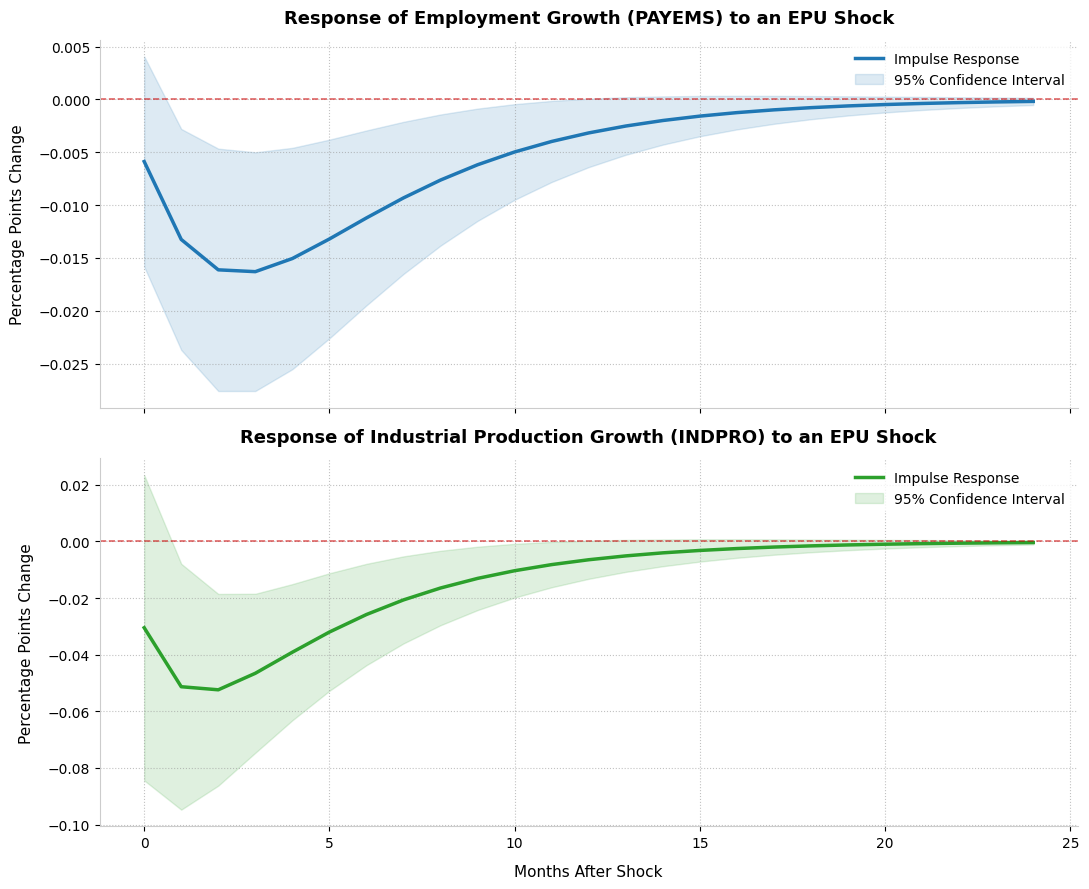

In [13]:

# 1. Compute the Impulse Responses (Extracting the raw structural calculations)
irf = results.irf(periods=24)
steps = np.arange(25)  # 24 horizons = 25 plot points including step 0

# Find variable index positions from your model
epu_idx = results.names.index('EPU')
payems_idx = results.names.index('PAYEMS_growth')
indpro_idx = results.names.index('INDPRO_growth')

# Extract exact values calculated by statsmodels
irf_payems = irf.orth_irfs[:, payems_idx, epu_idx]
irf_indpro = irf.orth_irfs[:, indpro_idx, epu_idx]

# CRITICAL FIX: Extract the orthogonalized standard errors using the proper method
orth_errors = irf.stderr(orth=True)
se_payems = orth_errors[:, payems_idx, epu_idx]
se_indpro = orth_errors[:, indpro_idx, epu_idx]

# 2. Create a clean, single figure with a 2x1 subplot grid
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
ax1, ax2 = axes

# Set custom colors for a professional look
colors = {'PAYEMS': '#1f77b4', 'INDPRO': '#2ca02c', 'baseline': '#cc0000'}

# --- Subplot 1: PAYEMS ---
ax1.plot(steps, irf_payems, color=colors['PAYEMS'], linewidth=2.5, label='Impulse Response')
ax1.fill_between(steps, 
                 irf_payems - 1.96 * se_payems, 
                 irf_payems + 1.96 * se_payems, 
                 color=colors['PAYEMS'], alpha=0.15, label='95% Confidence Interval')
ax1.set_title("Response of Employment Growth (PAYEMS) to an EPU Shock", fontsize=13, fontweight='bold', pad=12)

# --- Subplot 2: INDPRO ---
ax2.plot(steps, irf_indpro, color=colors['INDPRO'], linewidth=2.5, label='Impulse Response')
ax2.fill_between(steps, 
                 irf_indpro - 1.96 * se_indpro, 
                 irf_indpro + 1.96 * se_indpro, 
                 color=colors['INDPRO'], alpha=0.15, label='95% Confidence Interval')
ax2.set_title("Response of Industrial Production Growth (INDPRO) to an EPU Shock", fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel("Months After Shock", fontsize=11, labelpad=10)

# 3. Global Polish and Cleanup Loop
for ax in [ax1, ax2]:
    ax.set_ylabel("Percentage Points Change", fontsize=11, labelpad=10)
    
    # Add a clean red zero-baseline line
    ax.axhline(0, color=colors['baseline'], linestyle='--', linewidth=1.2, alpha=0.6)
    
    # Grid lines and border cleanup
    ax.grid(True, linestyle=':', alpha=0.6, color='#999999')
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

# Make spacing snug and eliminate clipping
plt.tight_layout()
plt.show()

## Part II

#### 1. Unconditional Forecasts

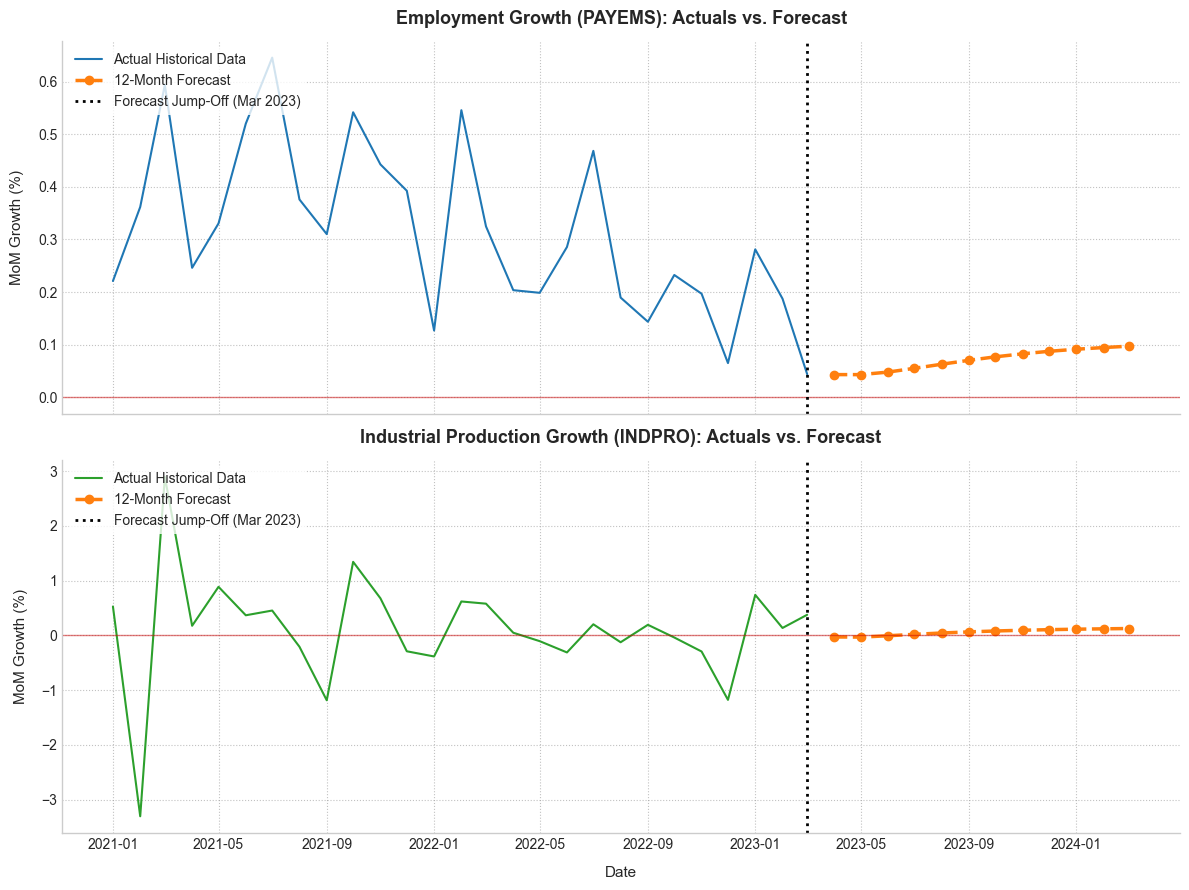

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Forecasting Logic (Same as before)
lag_order = results.k_ar
forecast_input = var_data.loc[:'2023-03-01'].values[-lag_order:]
forecast_values = results.forecast(y=forecast_input, steps=12)

forecast_dates = pd.date_range(start='2023-04-01', periods=12, freq='MS')
forecast_df = pd.DataFrame(forecast_values, index=forecast_dates, columns=results.names)

# 2. Extract historical data for context 
# (Starting from 2015 so the 12-month forecast isn't visually squished)
history_df = var_data.loc['2021-01-01':]

# 3. Create the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Define colors (added an orange color to make the forecast pop)
colors = {'PAYEMS': '#1f77b4', 'INDPRO': '#2ca02c', 'baseline': '#cc0000', 'forecast': '#ff7f0e'}
jump_off_date = pd.to_datetime('2023-03-01')

# --- Plot 1: PAYEMS ---
# Plot historical actuals
axes[0].plot(history_df.index, history_df['PAYEMS_growth'], color=colors['PAYEMS'], lw=1.5, label='Actual Historical Data')
# Plot the forecast
axes[0].plot(forecast_df.index, forecast_df['PAYEMS_growth'], color=colors['forecast'], marker='o', lw=2.5, linestyle='--', label='12-Month Forecast')

axes[0].set_title("Employment Growth (PAYEMS): Actuals vs. Forecast", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("MoM Growth (%)", fontsize=11, labelpad=10)

# --- Plot 2: INDPRO ---
# Plot historical actuals
axes[1].plot(history_df.index, history_df['INDPRO_growth'], color=colors['INDPRO'], lw=1.5, label='Actual Historical Data')
# Plot the forecast
axes[1].plot(forecast_df.index, forecast_df['INDPRO_growth'], color=colors['forecast'], marker='o', lw=2.5, linestyle='--', label='12-Month Forecast')

axes[1].set_title("Industrial Production Growth (INDPRO): Actuals vs. Forecast", fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel("MoM Growth (%)", fontsize=11, labelpad=10)
axes[1].set_xlabel("Date", fontsize=11, labelpad=10)

# --- Global Styling for both plots ---
for ax in axes:
    # Add zero-baseline
    ax.axhline(0, color=colors['baseline'], linestyle='-', linewidth=1, alpha=0.5)
    
    # Add vertical line showing where the forecast starts
    ax.axvline(jump_off_date, color='black', linestyle=':', linewidth=2, label='Forecast Jump-Off (Mar 2023)')
    
    # Formatting
    ax.grid(True, linestyle=':', alpha=0.6, color='#999999')
    ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

#### 2. Conditional Forecasting

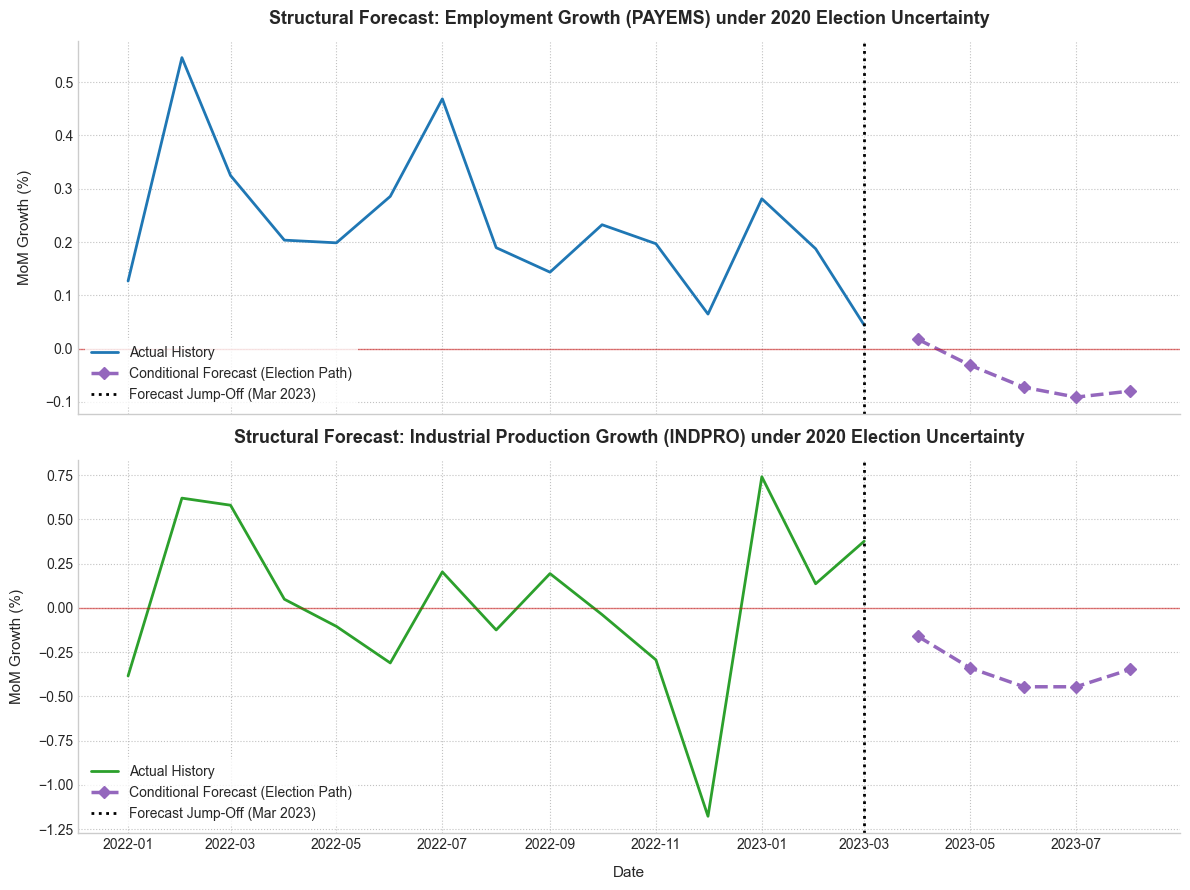

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract the EPU path from the 2020 election period (Oct 2020 to Feb 2021)
# We use results.names[0] to ensure we grab the exact string your model uses for EPU
epu_col = results.names[0] 
target_epu_path = var_data.loc['2020-10-01':'2021-02-01', epu_col].values

# 2. Set up the jump-off point (up to March 2023)
lag_order = results.k_ar
current_input = var_data.loc[:'2023-03-01'].dropna().values[-lag_order:]

# 3. Get the Cholesky decomposition matrix (P) from the estimated VAR residuals
# This matrix tells us how a shock to EPU spills over to the other variables
P = np.linalg.cholesky(results.sigma_u.values if hasattr(results.sigma_u, 'values') else results.sigma_u)

# 4. Run the Conditional Forecast step-by-step
conditional_forecasts = []

for i in range(len(target_epu_path)):
    # A. Calculate the baseline unconditional 1-step forecast
    y_hat = results.forecast(y=current_input, steps=1)[0]
    
    # B. Calculate how much EPU missed the 2020 target path
    # EPU is at index 0. The difference is the pure "structural shock"
    epu_shock = target_epu_path[i] - y_hat[0]
    
    # C. Push this shock through the Cholesky matrix
    structural_epsilon = epu_shock / P[0, 0]
    impact_vector = P[:, 0] * structural_epsilon
    
    # D. Add the structural impact to the baseline forecast
    y_conditional = y_hat + impact_vector
    
    # Store the result and update the input array for the next month
    conditional_forecasts.append(y_conditional)
    current_input = np.vstack([current_input[1:], y_conditional])

# 5. Format the output into a clean DataFrame
cond_dates = pd.date_range(start='2023-04-01', periods=5, freq='MS')
cond_df = pd.DataFrame(conditional_forecasts, index=cond_dates, columns=results.names)

# 6. Extract recent historical data for context (Starting from 2022)
history_df = var_data.loc['2022-01-01':'2023-03-01']

# 7. Plotting the Structural Forecasts for PAYEMS and INDPRO
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

colors = {'PAYEMS': '#1f77b4', 'INDPRO': '#2ca02c', 'baseline': '#cc0000', 'forecast': '#9467bd'}
jump_off_date = pd.to_datetime('2023-03-01')

# --- Plot 1: PAYEMS ---
axes[0].plot(history_df.index, history_df['PAYEMS_growth'], color=colors['PAYEMS'], lw=2, label='Actual History')
axes[0].plot(cond_df.index, cond_df['PAYEMS_growth'], color=colors['forecast'], marker='D', lw=2.5, linestyle='--', label='Conditional Forecast (Election Path)')
axes[0].set_title("Structural Forecast: Employment Growth (PAYEMS) under 2020 Election Uncertainty", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("MoM Growth (%)", fontsize=11, labelpad=10)

# --- Plot 2: INDPRO ---
axes[1].plot(history_df.index, history_df['INDPRO_growth'], color=colors['INDPRO'], lw=2, label='Actual History')
axes[1].plot(cond_df.index, cond_df['INDPRO_growth'], color=colors['forecast'], marker='D', lw=2.5, linestyle='--', label='Conditional Forecast (Election Path)')
axes[1].set_title("Structural Forecast: Industrial Production Growth (INDPRO) under 2020 Election Uncertainty", fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel("MoM Growth (%)", fontsize=11, labelpad=10)
axes[1].set_xlabel("Date", fontsize=11, labelpad=10)

# --- Global Styling ---
for ax in axes:
    ax.axhline(0, color=colors['baseline'], linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(jump_off_date, color='black', linestyle=':', linewidth=2, label='Forecast Jump-Off (Mar 2023)')
    ax.grid(True, linestyle=':', alpha=0.6, color='#999999')
    ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()